# Feature space & unsupervised learning techniques

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

RANDOM_SEED = 315

## 1. Iris dataset

In [ ]:
dataset_path = '../../data/clean-iris.csv'
data_df = pd.read_csv(dataset_path)
data_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),specie
0,-0.900681,1.019004,-1.340227,-1.315444,0
1,-1.143017,-0.131979,-1.340227,-1.315444,0
2,-1.385353,0.328414,-1.397064,-1.315444,0
3,-1.506521,0.098217,-1.283389,-1.315444,0
4,-1.021849,1.249201,-1.340227,-1.315444,0


### 1.1. 2D feature space

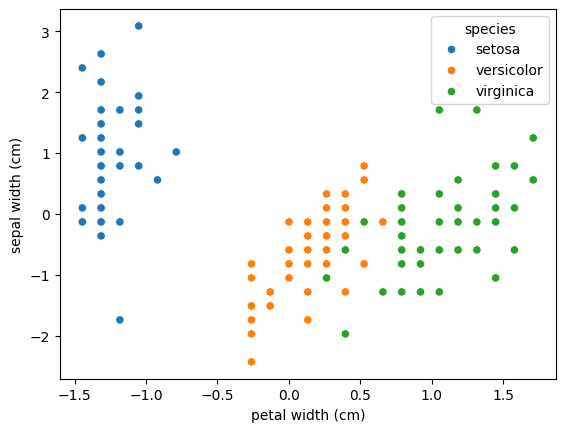

In [4]:
# Add the species name for the plot
data_df['species'] = data_df['specie'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
data_df.drop('specie', axis=1, inplace=True)

sns.scatterplot(data_df, x='petal width (cm)', y='sepal width (cm)', hue='species')
plt.show()

### 1.2. 3D feature space

In [5]:
fig = px.scatter_3d(
    data_df,
    x='petal width (cm)',
    y='petal length (cm)',
    z='sepal width (cm)',
    color='species',
    width=700,
    height=700,
    opacity=0.8
)

fig.update_layout()
fig.show()

## 2. Unsupervised clustering: k-means

In [6]:
# Drop the species label from the dataframe
data_df.drop('species', axis=1, inplace=True)

# Cluster the data
kmeans_model = KMeans(n_clusters=3, n_init='auto', max_iter=5000, random_state=RANDOM_SEED)
kmeans_fit_result = kmeans_model.fit(data_df)

# Extract the cluster centers
clusters_df = pd.DataFrame(kmeans_model.cluster_centers_, columns=data_df.columns)

# Add cluster membership to the data
data_df['cluster'] = kmeans_model.labels_

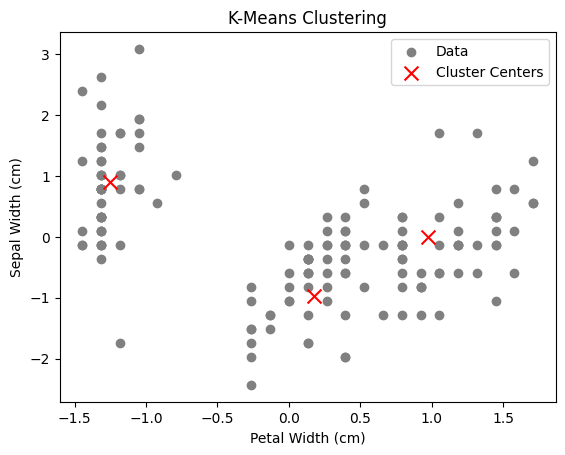

In [7]:
plt.title('K-Means Clustering')

plt.scatter(data_df['petal width (cm)'], data_df['sepal width (cm)'], c='grey', label='Data')
plt.scatter(clusters_df['petal width (cm)'], clusters_df['sepal width (cm)'], marker='x', s=100, c='red', label='Cluster Centers')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

## 3. Dimensionality reduction: PCA

/tmp/ipykernel_473769/1885984823.py:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


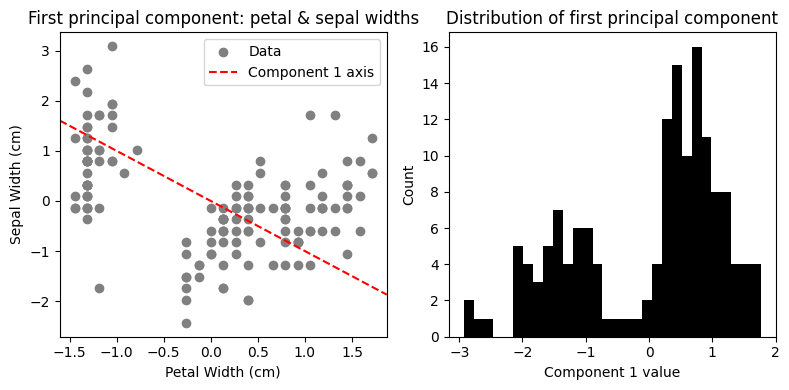

In [8]:
N = len(data_df)
x_data = data_df['petal width (cm)']
y_data = data_df['sepal width (cm)']
x_data = np.reshape(x_data, (len(data_df), 1))
y_data = np.reshape(y_data, (len(data_df), 1))
data = np.hstack((x_data, y_data))

mu = data.mean(axis=0)
data = data - mu

eigenvectors, eigenvalues, V = np.linalg.svd(data.T, full_matrices=False)
projected_data = np.dot(data, eigenvectors)
sigma = projected_data.std(axis=0).mean()
axis = eigenvectors[:, 0]
start, end = mu, mu + sigma * axis

pca_df = data_df[['petal width (cm)', 'sepal width (cm)']]
pca = PCA()
pca_data = pca.fit_transform(pca_df)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(1,2, figsize=(8, 4))

ax[0].set_title('First principal component: petal & sepal widths')
ax[0].scatter(x_data, y_data, color='grey', label='Data')
ax[0].axline(xy1=start, xy2=end, color='red', linestyle='--', label='Component 1 axis')
ax[0].set_xlabel('Petal Width (cm)')
ax[0].set_ylabel('Sepal Width (cm)')
ax[0].legend()

ax[1].set_title('Distribution of first principal component')
ax[1].hist(pca_df['PC1'], bins=30, color='black')
ax[1].set_xlabel('Component 1 value')
ax[1].set_ylabel('Count')

fig.tight_layout()
fig.show()